In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.read_csv("C:\\Users\\danan\\OneDrive\\Desktop\\ML\\Employee Attrition Prediction Dataset.csv")

print("Shape:", df.shape)
df.head()


Shape: (74498, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [3]:
# Check data types
print(df.dtypes)

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)


Employee ID                  int64
Age                          int64
Gender                      object
Years at Company             int64
Job Role                    object
Monthly Income               int64
Work-Life Balance           object
Job Satisfaction            object
Performance Rating          object
Number of Promotions         int64
Overtime                    object
Distance from Home           int64
Education Level             object
Marital Status              object
Number of Dependents         int64
Job Level                   object
Company Size                object
Company Tenure               int64
Remote Work                 object
Leadership Opportunities    object
Innovation Opportunities    object
Company Reputation          object
Employee Recognition        object
Attrition                   object
dtype: object
Categorical columns: ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital

In [5]:
# Ordinal features (Label Encoding)
ordinal_features = ["Work-Life Balance","Job Satisfaction","Performance Rating","Education Leve","Company Reputation","Employee Recognition"]

#Label encoding
ordinal_mappings = {
    "Work-Life Balance": {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "Job Satisfaction": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4},
    "Performance Rating": {"Low": 1, "Below Average": 2, "Average": 3, "High": 4},
    "Education Level": {"High School": 1, "Associate Degree": 2, "Bachelorâ€™s Degree": 3,"Masterâ€™s Degree":4,"PhD":5},
    "Company Reputation": {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "Employee Recognition": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
}

for col, mapping in ordinal_mappings.items():
    df[col + '_Enc'] = df[col].map(mapping)
print("After encoding more columns shape:", df.shape)
df.head()

After encoding more columns shape: (74498, 30)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,Work-Life Balance_Enc,Job Satisfaction_Enc,Performance Rating_Enc,Education Level_Enc,Company Reputation_Enc,Employee Recognition_Enc
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,No,Excellent,Medium,Stayed,4,2,3,2,4,2
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,No,Fair,Low,Stayed,1,3,1,4,2,1
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,No,Poor,Low,Stayed,3,3,1,3,1,1
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,No,Good,Medium,Stayed,3,3,4,1,3,2
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,No,Fair,Medium,Stayed,2,4,3,1,2,2


In [7]:
# Binary columns (Yes/No) 
binary_features = ["Overtime","Remote Work","Leadership Opportunities","Innovation Opportunities"]
# Binary encoding (Label encoding)
for col in binary_features:
    df[col + '_Enc'] = df[col].map({'No': 0, 'Yes': 1})
print("After encoding more columns shape:", df.shape)
df.head()

After encoding more columns shape: (74498, 34)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Work-Life Balance_Enc,Job Satisfaction_Enc,Performance Rating_Enc,Education Level_Enc,Company Reputation_Enc,Employee Recognition_Enc,Overtime_Enc,Remote Work_Enc,Leadership Opportunities_Enc,Innovation Opportunities_Enc
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,4,2,3,2,4,2,0,0,0,0
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,1,3,1,4,2,1,0,0,0,0
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,3,1,3,1,1,0,0,0,0
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,3,3,4,1,3,2,0,1,0,0
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,2,4,3,1,2,2,1,0,0,0


In [9]:
# Target column
target_col = "Attrition"
# Target encoding(Label encoding)
df["Attrition_Enc"]=df[target_col].map({"Stayed": 1, "Left": 0})
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Job Satisfaction_Enc,Performance Rating_Enc,Education Level_Enc,Company Reputation_Enc,Employee Recognition_Enc,Overtime_Enc,Remote Work_Enc,Leadership Opportunities_Enc,Innovation Opportunities_Enc,Attrition_Enc
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,2,3,2,4,2,0,0,0,0,1
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,1,4,2,1,0,0,0,0,1
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,1,3,1,1,0,0,0,0,1
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,3,4,1,3,2,0,1,0,0,1
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,4,3,1,2,2,1,0,0,0,1


In [11]:
# Nominal features 
nominal_features =["Gender","Job Role","Marital Status","Company Size","Job Level"]

# One-Hot Encoding encoding
df = pd.get_dummies(df, columns=nominal_features, drop_first=True)

print("After encoding more columns shape:", df.shape)
df.head()

After encoding more columns shape: (74498, 41)


,Employee ID,Age,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,...,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Marital Status_Married,Marital Status_Single,Company Size_Medium,Company Size_Small,Job Level_Mid,Job Level_Senior
0,8410,31,19,5390,Excellent,Medium,Average,2,No,22,...,False,False,False,False,True,False,True,False,True,False
1,64756,59,4,5534,Poor,High,Low,3,No,21,...,False,False,True,False,False,False,True,False,True,False
2,30257,24,10,8159,Good,High,Low,0,No,11,...,False,True,False,False,True,False,True,False,True,False
3,65791,36,7,3989,Good,High,High,1,No,27,...,False,False,False,False,False,True,False,True,True,False
4,65026,56,41,4821,Fair,Very High,Average,0,Yes,71,...,False,False,False,False,False,False,True,False,False,True


In [13]:
print(df.columns.tolist())

['Employee ID', 'Age', 'Years at Company', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Number of Dependents', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition', 'Work-Life Balance_Enc', 'Job Satisfaction_Enc', 'Performance Rating_Enc', 'Education Level_Enc', 'Company Reputation_Enc', 'Employee Recognition_Enc', 'Overtime_Enc', 'Remote Work_Enc', 'Leadership Opportunities_Enc', 'Innovation Opportunities_Enc', 'Attrition_Enc', 'Gender_Male', 'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media', 'Job Role_Technology', 'Marital Status_Married', 'Marital Status_Single', 'Company Size_Medium', 'Company Size_Small', 'Job Level_Mid', 'Job Level_Senior']


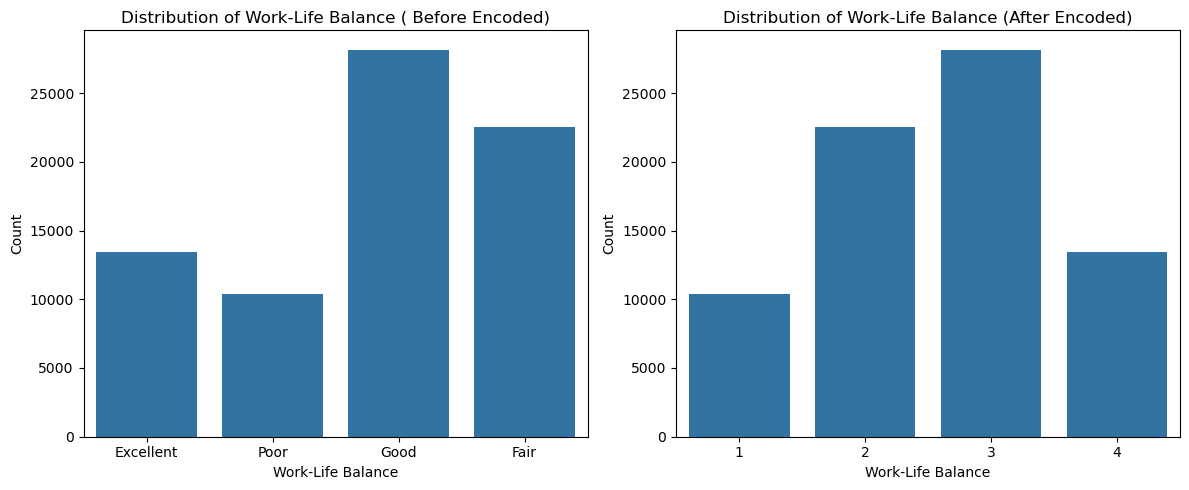

In [15]:
#Visualization for Label encoding
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x="Work-Life Balance", data=df)
plt.title("Distribution of Work-Life Balance ( Before Encoded)")
plt.xlabel("Work-Life Balance")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.countplot(x="Work-Life Balance_Enc", data=df)
plt.title("Distribution of Work-Life Balance (After Encoded)")
plt.xlabel("Work-Life Balance")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


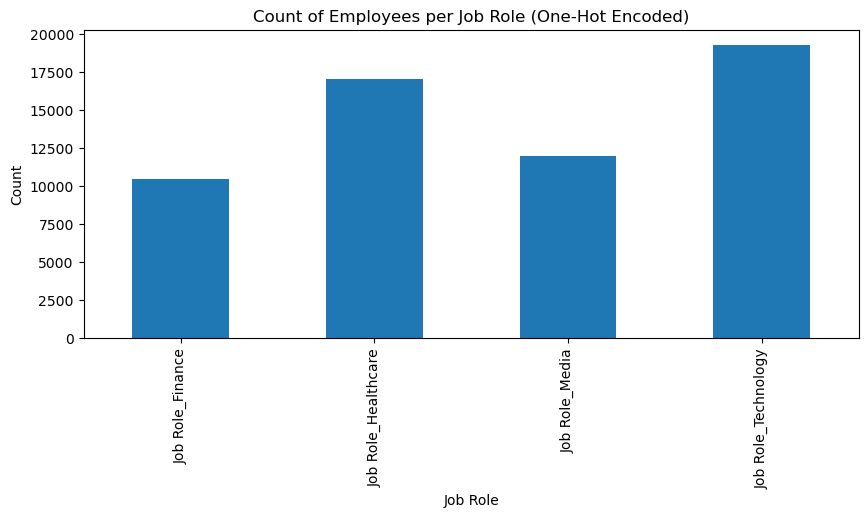

In [17]:
#Visualization for One-Hot Encodeing 
job_role_cols = [col for col in df.columns if 'Job Role_' in col]

plt.figure(figsize=(10,4))
df[job_role_cols].sum().plot(kind='bar')
plt.title("Count of Employees per Job Role (One-Hot Encoded)")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.show()

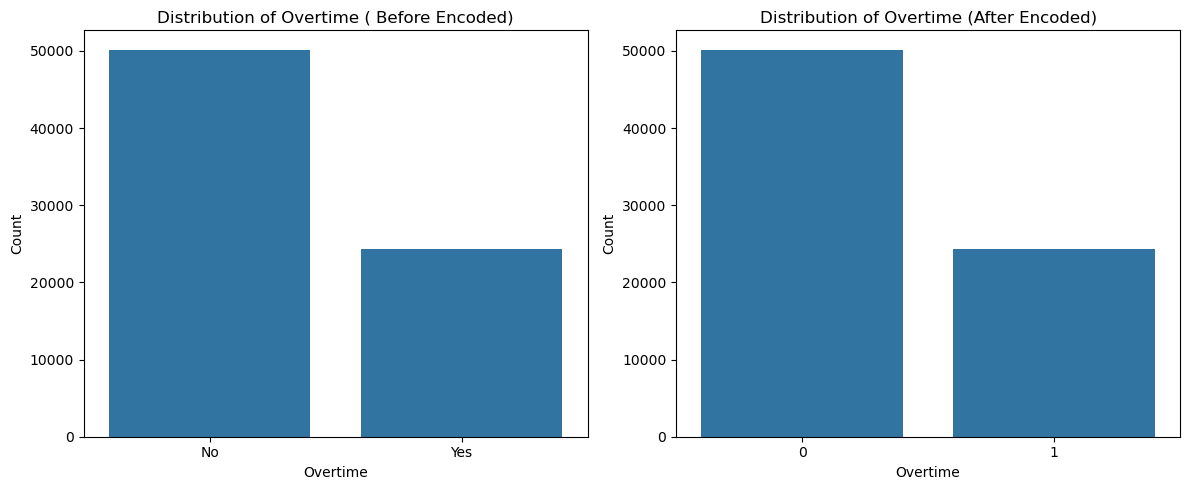

In [19]:
#Visualization for Binary encoding
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x="Overtime", data=df)
plt.title("Distribution of Overtime ( Before Encoded)")
plt.xlabel("Overtime")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.countplot(x="Overtime_Enc", data=df)
plt.title("Distribution of Overtime (After Encoded)")
plt.xlabel("Overtime")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [21]:
output_path = "C:\\Users\\danan\\OneDrive\\Desktop\\ML\\Employee Attrition Prediction Dataset.csv"
df.to_csv(output_path, index=False)
